# 8 – Temporal Predictive Power
**Research question:** Do behaviors in the *first* N minutes of a session predict team-joining as well as behaviors from the *last* N minutes? And does 5 min outperform 1 min?

| Window | Source |
|--------|--------|
| First 1 min | chunk1 utterances with start_time < 60 s |
| First 5 min | chunk1 utterances with start_time < 300 s |
| Last 5 min  | last chunk utterances with start_time ≥ (max − 300 s) |
| Last 1 min  | last chunk utterances with start_time ≥ (max − 60 s) |
| Full session | all chunks (baseline) |

**Model:** LOCO-CV logistic regression, n=579 non-fac, same pipeline as main analysis.


In [1]:
import json, re, unicodedata, warnings
from collections import defaultdict
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             accuracy_score, f1_score)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

BASE        = Path("/Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis")
FEATURE_DIR = BASE / "analysis_v2/data/person-aggregation-features"
FIG_DIR     = BASE / "analysis_v2/figures/person-aggregation-features"
OUTPUTS_DIR = BASE / "outputs"
BY_CONF     = BASE / "finalized_matching_csvs/global_participant_identity_by_conference.csv"
ALIAS_PATH  = BASE / "participant_alias_mapping.csv"
FIG_DIR.mkdir(parents=True, exist_ok=True)

NAVY = "#1E2761"; TEAL = "#028090"; ORANGE = "#E07B4A"; GRAY = "#AAAAAA"; LIGHT_BG = "#F4F7FB"
print("Imports OK")


Imports OK


In [2]:
# ── name helpers + identity lookup ────────────────────────────────────────────
def norm_name(text):
    s = "" if text is None else str(text)
    s = unicodedata.normalize("NFKD", s).encode("ascii","ignore").decode("ascii")
    s = s.lower().strip()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()

alias_map = {}
if ALIAS_PATH.exists():
    for _, r in pd.read_csv(ALIAS_PATH).iterrows():
        a, c = norm_name(r.get("alias_name")), norm_name(r.get("canonical_name"))
        if a and c: alias_map[a] = c

def resolve_alias(name):
    cur, seen = name, set()
    while cur in alias_map and cur not in seen:
        seen.add(cur); cur = alias_map[cur]
    return cur

map_df = pd.read_csv(BY_CONF)
map_df["conference"] = map_df["conference"].astype(str).str.strip()
map_df["normalized_name"] = map_df["normalized_name"].astype(str).map(norm_name).map(resolve_alias)
lookup = {(r["conference"], r["normalized_name"]): r["global_person_id"]
          for _, r in map_df.iterrows()}

def parse_ts_start(ts_str: str) -> float:
    try:
        start = ts_str.split("-")[0].strip()
        mm, ss = start.split(":")
        return int(mm)*60 + int(ss)
    except Exception:
        return np.nan

print("Helpers OK")


Helpers OK


In [3]:
# ── group JSON files by session ───────────────────────────────────────────────
sessions = defaultdict(list)
for conf_dir in sorted(OUTPUTS_DIR.glob("*")):
    if not conf_dir.is_dir(): continue
    conf = conf_dir.name
    for jp in conf_dir.rglob("*.json"):
        key = (conf, re.sub(r"_chunk\d+$", "", jp.stem))
        sessions[key].append(jp)
print(f"Total sessions: {len(sessions)}")

WINDOWS = {
    "first_1min": ("first", 60),
    "first_5min": ("first", 300),
    "last_5min":  ("last",  300),
    "last_1min":  ("last",  60),
}

records = []
for (conf, sess_key), files in sessions.items():
    def chunk_order(p):
        m = re.search(r"_chunk(\d+)$", p.stem)
        return int(m.group(1)) if m else 0
    files_sorted = sorted(files, key=chunk_order)
    first_chunk  = files_sorted[0]
    last_chunk   = files_sorted[-1]

    for win_name, (edge, dur_s) in WINDOWS.items():
        chunk_file = first_chunk if edge == "first" else last_chunk
        try:
            payload = json.loads(chunk_file.read_text())
        except Exception:
            continue
        utts = payload.get("utterance_annotations", [])
        if not utts: continue

        all_starts = [parse_ts_start(u.get("timestamp","")) for u in utts]
        all_starts = [s for s in all_starts if not np.isnan(s)]
        if not all_starts: continue
        max_start = max(all_starts)

        for utt in utts:
            ts = parse_ts_start(utt.get("timestamp",""))
            if np.isnan(ts): continue
            if edge == "first" and ts >= dur_s: continue
            if edge == "last"  and ts < (max_start - dur_s): continue

            sp  = resolve_alias(norm_name(utt.get("speaker","")))
            pid = lookup.get((conf, sp))
            if not pid: continue

            for code in (utt.get("codes") or []):
                sc = code.get("subcode") or code.get("sub_code")
                if not sc or str(sc).strip().lower() in ("none","na",""): continue
                sc_col = "subcode__" + re.sub(r"[\s\-]+","_", str(sc).strip().lower())
                records.append({"conference": conf, "global_person_id": pid,
                                 "window": win_name, "subcode": sc_col})

print(f"Records collected: {len(records):,}")
pd.DataFrame(records)["window"].value_counts()


Total sessions: 276
Records collected: 10,680


window
last_5min     4298
first_5min    3910
last_1min     1389
first_1min    1083
Name: count, dtype: int64

In [4]:
# ── pivot to person x subcode count matrices per window ───────────────────────
rec_df = pd.DataFrame(records)
window_dfs = {}
for win in WINDOWS:
    w = rec_df[rec_df["window"] == win]
    if w.empty: continue
    counts = (w.groupby(["conference","global_person_id","subcode"])
               .size().reset_index(name="count"))
    pivot = counts.pivot_table(
        index=["conference","global_person_id"],
        columns="subcode", values="count", fill_value=0
    ).reset_index()
    pivot.columns.name = None
    window_dfs[win] = pivot
    print(f"  {win:12s}: {len(pivot)} person-sessions, {pivot.shape[1]-2} subcodes")

base_features = pd.read_csv(FEATURE_DIR / "person_codename_features.csv")
subcode_cols_all = [c for c in base_features.columns
                    if c.startswith("subcode__") and c != "subcode__none"]
print(f"\nFull-session: {len(base_features)} rows, {len(subcode_cols_all)} subcodes")


  first_1min  : 239 person-sessions, 46 subcodes
  first_5min  : 478 person-sessions, 57 subcodes
  last_5min   : 424 person-sessions, 60 subcodes
  last_1min   : 305 person-sessions, 52 subcodes

Full-session: 639 rows, 69 subcodes


In [5]:
# ── LOCO + statsmodels helpers ─────────────────────────────────────────────────
def p_to_stars(p):
    if pd.isna(p): return ""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

def run_loco(data, feature_cols, target="outcome_joined_team"):
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("scl", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))])
    yt, ys, yp = [], [], []
    for holdout in sorted(data["conference"].dropna().unique()):
        tr = data[data["conference"] != holdout]
        te = data[data["conference"] == holdout]
        if tr.empty or te.empty or tr[target].nunique() < 2: continue
        pipe.fit(tr[feature_cols], tr[target].astype(int))
        p = pipe.predict_proba(te[feature_cols])[:,1]
        yt.extend(te[target].astype(int).tolist())
        ys.extend(p.tolist())
        yp.extend((p>=0.5).astype(int).tolist())
    yt, ys, yp = np.array(yt), np.array(ys), np.array(yp)
    if len(np.unique(yt)) < 2:
        return dict(auc=np.nan, auprc=np.nan, acc=np.nan, f1=np.nan, n=len(data))
    return dict(auc=roc_auc_score(yt,ys), auprc=average_precision_score(yt,ys),
                acc=accuracy_score(yt,yp), f1=f1_score(yt,yp,zero_division=0), n=len(data))

def fit_sm_coefs(data, feature_cols, target="outcome_joined_team"):
    X = data[feature_cols].copy().fillna(data[feature_cols].median(numeric_only=True))
    std = X.std(ddof=0).replace(0,1.0)
    Xz = sm.add_constant((X-X.mean())/std, has_constant="add")
    y = data[target].astype(int).values
    try:
        fit = sm.Logit(y, Xz).fit(disp=0, maxiter=400)
    except Exception as e:
        print(f"  statsmodels failed: {e}"); return pd.DataFrame()
    params = fit.params.drop("const", errors="ignore")
    pvals  = fit.pvalues.drop("const", errors="ignore")
    out = pd.DataFrame({"feature": params.index, "coef": params.values,
                        "pvalue": pvals.reindex(params.index).values})
    out["stars"] = out["pvalue"].map(p_to_stars)
    return out

print("Helpers ready")


Helpers ready


In [6]:
# ── run all models ─────────────────────────────────────────────────────────────
TARGET   = "outcome_joined_team"
controls = ["n_sessions_attended","speaking_minutes_total"]
base_nf  = base_features[base_features["is_facilitator"] == 0].copy()
subcode_eligible = [c for c in subcode_cols_all if base_nf[c].sum() >= 10]

results  = {}
win_coefs = {}
LABELS = {"first_1min":"First 1 min","first_5min":"First 5 min",
          "full_session":"Full session","last_5min":"Last 5 min","last_1min":"Last 1 min"}

# full-session baseline
print("Full session baseline …")
m = run_loco(base_nf, controls + subcode_eligible, TARGET)
results["full_session"] = m
print(f"  AUC={m['auc']:.3f}  AUPRC={m['auprc']:.3f}  Acc={m['acc']*100:.1f}%  F1={m['f1']:.3f}")

# time windows — use the SAME subcode_eligible list as full-session (>=10 threshold)
# so we're comparing the same 57 features across all windows.
# Subcodes absent in the window for a person get count = 0.
for win_name in ["first_1min","first_5min","last_5min","last_1min"]:
    if win_name not in window_dfs: continue
    print(f"\n{LABELS[win_name]} …")
    merged = base_nf[["conference","global_person_id","outcome_joined_team",
                       "outcome_joined_funded_team"] + controls].merge(
        window_dfs[win_name], on=["conference","global_person_id"], how="left")
    # fill missing window counts with 0 for all eligible subcodes
    for c in subcode_eligible:
        if c not in merged.columns:
            merged[c] = 0
        else:
            merged[c] = merged[c].fillna(0)
    print(f"  {len(merged)} rows, {len(subcode_eligible)} subcodes (same set as full-session)")
    m = run_loco(merged, controls + subcode_eligible, TARGET)
    results[win_name] = m
    print(f"  AUC={m['auc']:.3f}  AUPRC={m['auprc']:.3f}  Acc={m['acc']*100:.1f}%  F1={m['f1']:.3f}")
    win_coefs[win_name] = fit_sm_coefs(merged, controls + subcode_eligible, TARGET)

print("\n✓ Done")

Full session baseline …


  AUC=0.833  AUPRC=0.813  Acc=75.5%  F1=0.746

First 1 min …
  579 rows, 57 subcodes (same set as full-session)


  AUC=0.731  AUPRC=0.672  Acc=68.2%  F1=0.669
  statsmodels failed: Singular matrix

First 5 min …
  579 rows, 57 subcodes (same set as full-session)


  AUC=0.779  AUPRC=0.742  Acc=71.7%  F1=0.705


  statsmodels failed: Singular matrix

Last 5 min …
  579 rows, 57 subcodes (same set as full-session)
  AUC=0.810  AUPRC=0.803  Acc=73.9%  F1=0.729


  statsmodels failed: Singular matrix

Last 1 min …
  579 rows, 57 subcodes (same set as full-session)
  AUC=0.762  AUPRC=0.729  Acc=71.2%  F1=0.701


  statsmodels failed: Singular matrix

✓ Done


In [7]:
# ── summary table ──────────────────────────────────────────────────────────────
order = ["first_1min","first_5min","full_session","last_5min","last_1min"]
rows = []
for k in order:
    if k not in results: continue
    m = results[k]
    rows.append({"Window": LABELS[k], "AUC": round(m["auc"],3),
                 "AUPRC": round(m["auprc"],3), "Accuracy": f"{m['acc']*100:.1f}%",
                 "F1": round(m["f1"],3)})
summary = pd.DataFrame(rows)
summary.to_csv(FEATURE_DIR / "temporal_window_model_summary.csv", index=False)
print(summary.to_string(index=False))
summary


      Window   AUC  AUPRC Accuracy    F1
 First 1 min 0.731  0.672    68.2% 0.669
 First 5 min 0.779  0.742    71.7% 0.705
Full session 0.833  0.813    75.5% 0.746
  Last 5 min 0.810  0.803    73.9% 0.729
  Last 1 min 0.762  0.729    71.2% 0.701


,Window,AUC,AUPRC,Accuracy,F1
0,First 1 min,0.731,0.672,68.2%,0.669
1,First 5 min,0.779,0.742,71.7%,0.705
2,Full session,0.833,0.813,75.5%,0.746
3,Last 5 min,0.810,0.803,73.9%,0.729
4,Last 1 min,0.762,0.729,71.2%,0.701


In [8]:
# ── bar chart (300 DPI for slides) ─────────────────────────────────────────────
plot_order = [k for k in ["first_1min","first_5min","full_session","last_5min","last_1min"] if k in results]
auc_vals   = [results[k]["auc"]   for k in plot_order]
auprc_vals = [results[k]["auprc"] for k in plot_order]
xlabels    = [LABELS[k] for k in plot_order]
x = np.arange(len(xlabels)); width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(LIGHT_BG); ax.set_facecolor(LIGHT_BG)

b1 = ax.bar(x-width/2, auc_vals,   width, label="AUC",   color=TEAL,   edgecolor="white")
b2 = ax.bar(x+width/2, auprc_vals, width, label="AUPRC", color=ORANGE, edgecolor="white")
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom",
            fontsize=9, color=NAVY, fontweight="bold")

if "full_session" in plot_order:
    fi = plot_order.index("full_session")
    ax.axvspan(fi-0.5, fi+0.5, color=GRAY, alpha=0.15, zorder=0)
    ax.text(fi, 0.28, "baseline", ha="center", fontsize=8, color="gray", style="italic")

ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=10)
ax.set_ylabel("Score", fontsize=10, color=NAVY)
ax.set_ylim(0, 1.05)
ax.set_title("Predictive Power by Time Window — LOCO-CV (n=579, non-fac)\nOutcome: Joined a Team",
             fontsize=12, fontweight="bold", color=NAVY, pad=10)
ax.legend(fontsize=9, frameon=True, framealpha=0.9)
ax.spines[["top","right"]].set_visible(False)
ax.axhline(0.5, color=GRAY, linestyle="--", linewidth=0.8)
ax.text(len(xlabels)-0.45, 0.505, "chance (0.5)", fontsize=7.5, color="gray", ha="right")
fig.tight_layout()

out_path = FIG_DIR / "temporal_window_comparison.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "temporal_window_comparison.pdf", bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

Saved /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/person-aggregation-features/temporal_window_comparison.png


Saved /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/person-aggregation-features/temporal_auc_lineplot.png


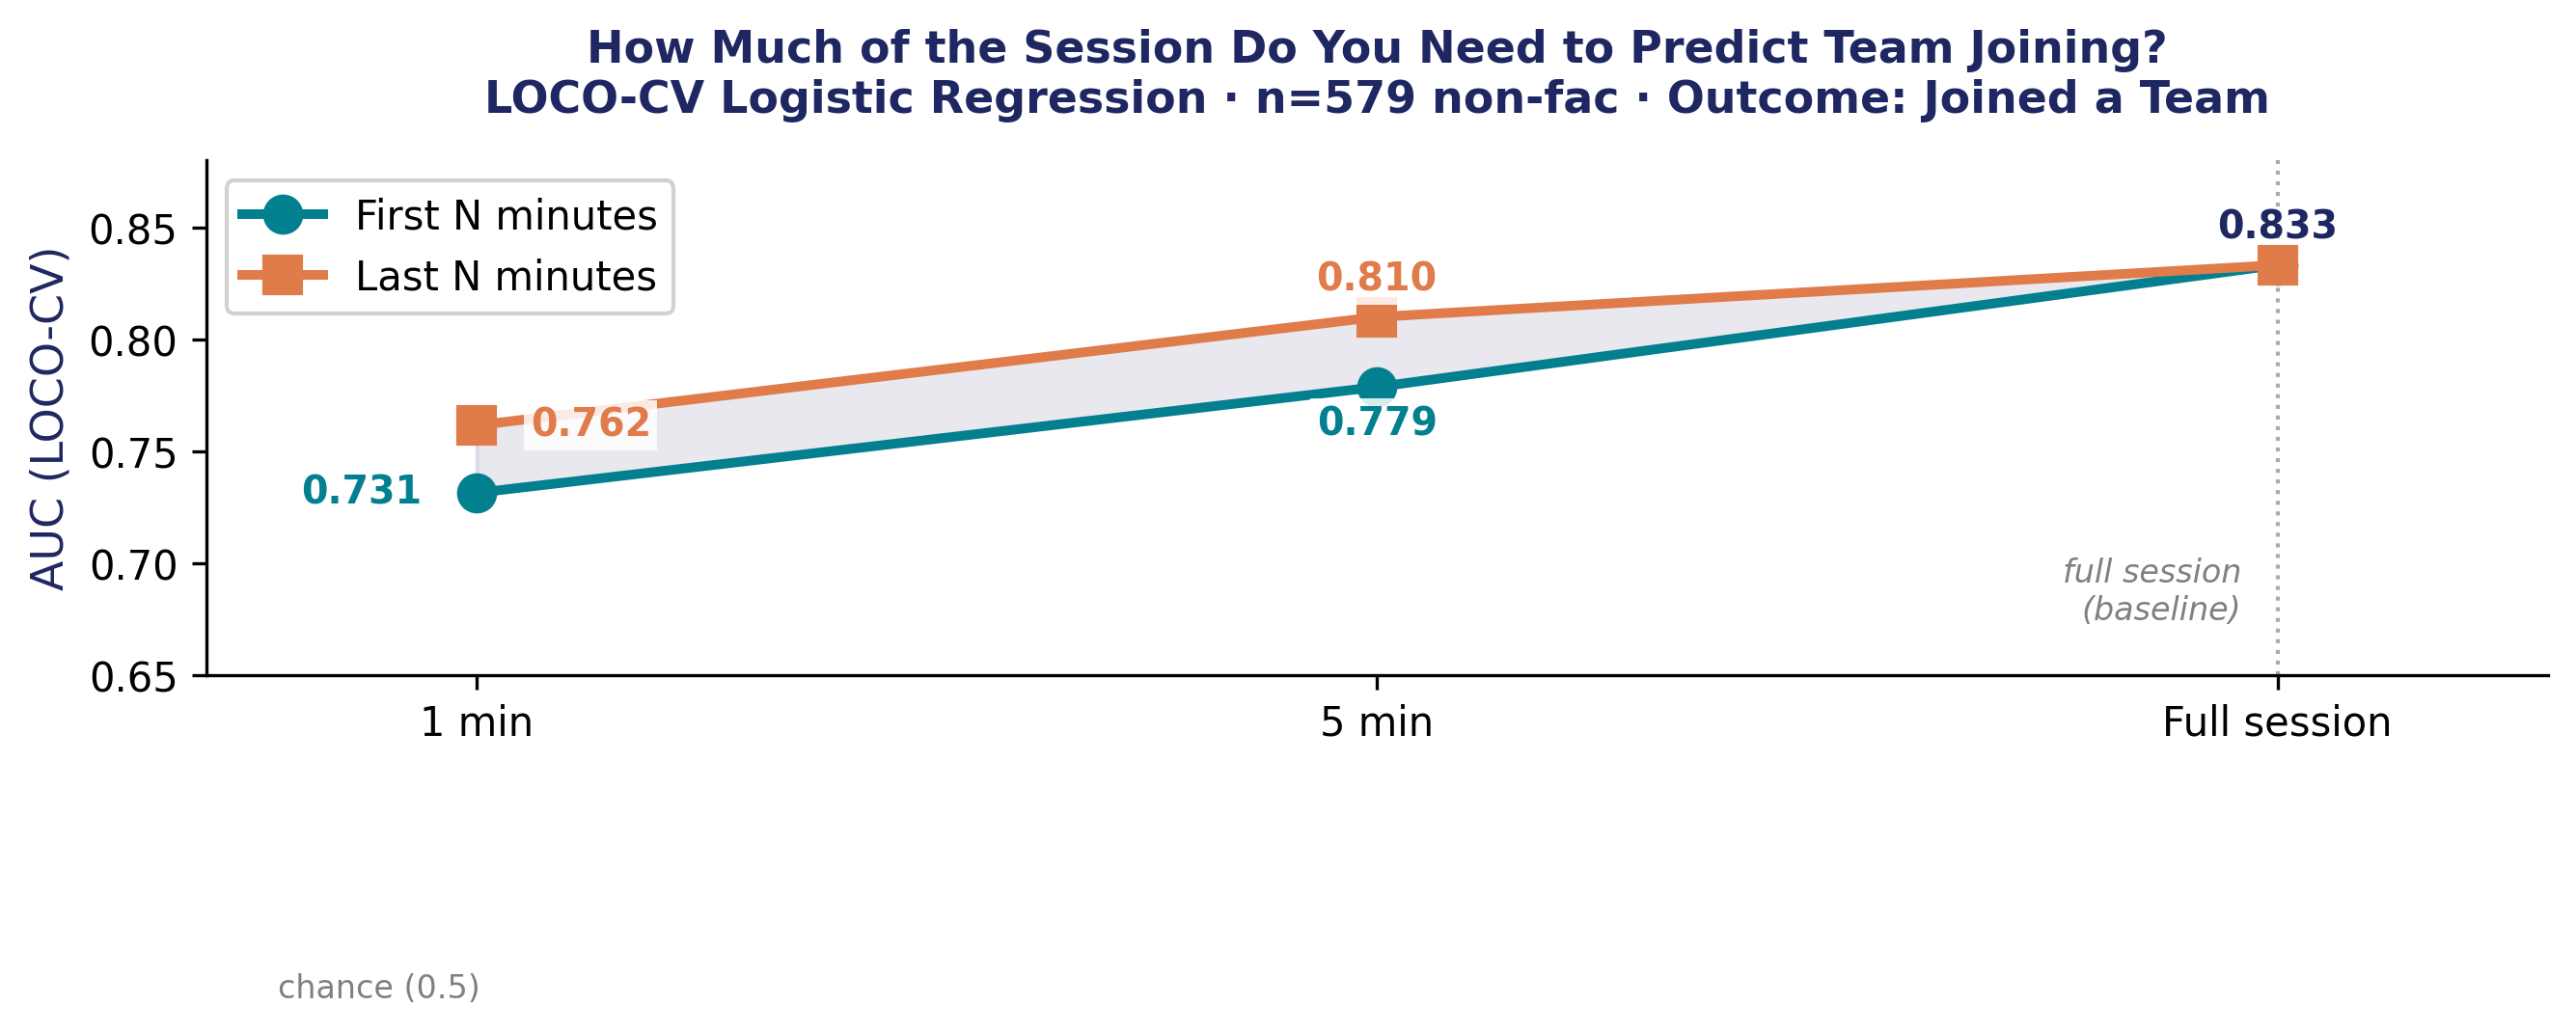

In [9]:
# ── line plot: AUC vs window duration, by position (start vs end) ─────────────
from IPython.display import Image, display

x_ticks  = [0, 1, 2]
x_labels = ["1 min", "5 min", "Full session"]

first_auc = [results["first_1min"]["auc"], results["first_5min"]["auc"], results["full_session"]["auc"]]
last_auc  = [results["last_1min"]["auc"],  results["last_5min"]["auc"],  results["full_session"]["auc"]]
full_auc  =  results["full_session"]["auc"]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# chance baseline
ax.axhline(0.5, color=GRAY, linestyle="--", linewidth=1, zorder=1)
ax.text(-0.22, 0.503, "chance (0.5)", fontsize=8, color="gray", va="bottom")

# shaded gap between lines
ax.fill_between(x_ticks, first_auc, last_auc, alpha=0.10, color=NAVY)

# lines (drawn after fill, before labels)
ax.plot(x_ticks, first_auc, color=TEAL,   marker="o", markersize=9,
        linewidth=2.4, label="First N minutes", zorder=3)
ax.plot(x_ticks, last_auc,  color=ORANGE, marker="s", markersize=9,
        linewidth=2.4, label="Last N minutes",  zorder=3)

# white bbox so labels always sit on top of the line
WB = dict(facecolor="white", edgecolor="none", pad=1.5, alpha=0.85)

label_cfg = [
    # (xi, value, color, ha, va, x_offset, y_offset, use_bbox)
    (0, first_auc[0], TEAL,   "right",  "center", -0.06,  0.000, False),  # first 1min — left of marker
    (0, last_auc[0],  ORANGE, "left",   "center",  0.06,  0.000, True),   # last 1min  — right, bbox over line
    (1, first_auc[1], TEAL,   "center", "top",     0.00, -0.008, True),   # first 5min — below
    (1, last_auc[1],  ORANGE, "center", "bottom",  0.00,  0.008, True),   # last 5min  — above
    (2, full_auc,     NAVY,   "center", "bottom",  0.00,  0.008, False),  # full session
]
for xi, val, col, ha, va, dx, dy, use_bbox in label_cfg:
    kwargs = dict(ha=ha, va=va, fontsize=9.5, color=col, fontweight="bold", zorder=5)
    if use_bbox:
        kwargs["bbox"] = WB
    ax.text(xi + dx, val + dy, f"{val:.3f}", **kwargs)

# full-session vertical marker
ax.axvline(2, color=GRAY, linestyle=":", linewidth=1, zorder=1)
ax.text(1.96, 0.672, "full session\n(baseline)", ha="right", fontsize=8,
        color="gray", style="italic", va="bottom")

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=11)
ax.set_ylabel("AUC (LOCO-CV)", fontsize=11, color=NAVY)
ax.set_ylim(0.65, 0.88)
ax.set_xlim(-0.3, 2.3)
ax.set_title(
    "How Much of the Session Do You Need to Predict Team Joining?\n"
    "LOCO-CV Logistic Regression · n=579 non-fac · Outcome: Joined a Team",
    fontsize=11, fontweight="bold", color=NAVY, pad=12,
)
ax.legend(fontsize=10, frameon=True, framealpha=0.9, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="both", labelsize=10)

fig.tight_layout()

line_png = FIG_DIR / "temporal_auc_lineplot.png"
line_pdf = FIG_DIR / "temporal_auc_lineplot.pdf"
fig.savefig(line_png, dpi=300, bbox_inches="tight")
fig.savefig(line_pdf,          bbox_inches="tight")
plt.show()
print(f"Saved {line_png}")
display(Image(filename=str(line_png)))

In [10]:
# ── significant behaviors per window (sklearn coefficients) ───────────────────
# statsmodels fails on sparse window data (singular matrix) because most people
# have zero counts for most subcodes in a short window.
# We fit a single sklearn logistic regression on the full non-fac dataset for
# each window instead — same pipeline (impute → scale → L2-LR), for interpretation.

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

TOPN = 15  # top features by |coef| to show per window

win_top_coefs = {}

for win_name in ["first_1min", "first_5min", "last_5min", "last_1min"]:
    if win_name not in window_dfs:
        continue
    merged = base_nf[["conference", "global_person_id", "outcome_joined_team",
                       "outcome_joined_funded_team"] + controls].merge(
        window_dfs[win_name], on=["conference", "global_person_id"], how="left")
    for c in subcode_eligible:
        if c not in merged.columns:
            merged[c] = 0
        else:
            merged[c] = merged[c].fillna(0)

    feat_cols = controls + subcode_eligible
    X = merged[feat_cols].copy()
    y = merged[TARGET].astype(int).values

    pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scl", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", C=1.0)),
    ])
    pipe.fit(X, y)

    coefs = pipe.named_steps["clf"].coef_[0]
    coef_df = pd.DataFrame({"feature": feat_cols, "coef": coefs})
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df[coef_df["feature"].isin(subcode_eligible)]  # drop controls
    coef_df = coef_df.sort_values("abs_coef", ascending=False).head(TOPN)
    coef_df["label"] = (coef_df["feature"]
                        .str.replace("subcode__", "")
                        .str.replace("_", " ")
                        .str.title())
    win_top_coefs[win_name] = coef_df

    m = results[win_name]
    print(f"\n{'='*60}")
    print(f"{LABELS[win_name]}  (AUC={m['auc']:.3f})  — Top {TOPN} subcodes by |coef|")
    print(f"{'='*60}")
    for _, r in coef_df.iterrows():
        direction = "+" if r["coef"] >= 0 else "-"
        print(f"  {direction} {r['label']:42s}  coef={r['coef']:+.3f}")


First 1 min  (AUC=0.731)  — Top 15 subcodes by |coef|
  + Checks Consensus                            coef=+0.666
  - Invites Contribution                        coef=-0.575
  - Encourages Participation                    coef=-0.466
  - Proposes Process                            coef=-0.375
  - Expertise Complementarity                   coef=-0.354
  + Returns To Earlier Idea                     coef=+0.315
  + Asks Rhetorical Question                    coef=+0.260
  + Manages Tension                             coef=+0.235
  + Attributes To Other                         coef=+0.221
  - Proposes Next Step                          coef=-0.217
  - Joint Framing                               coef=-0.214
  - Method Complementarity                      coef=-0.186
  + Asks For Elaboration                        coef=+0.183
  + Compares Options                            coef=+0.181
  + Funding Priority Alignment                  coef=+0.170

First 5 min  (AUC=0.779)  — Top 15 subcodes 

In [11]:
# ── per-window coefficient charts (top subcodes by |coef|) ────────────────────
for win_name in ["first_1min", "first_5min", "last_5min", "last_1min"]:
    coef_df = win_top_coefs.get(win_name)
    if coef_df is None or coef_df.empty:
        print(f"{LABELS[win_name]}: no data — skipping"); continue

    plot_df = coef_df.sort_values("coef")
    colors = [TEAL if c >= 0 else ORANGE for c in plot_df["coef"]]
    m = results[win_name]

    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df)*0.65 + 1.5)))
    fig.patch.set_facecolor(LIGHT_BG); ax.set_facecolor(LIGHT_BG)
    ax.barh(plot_df["label"], plot_df["coef"], color=colors, height=0.65,
            edgecolor="white", linewidth=0.5)
    ax.axvline(0, color=NAVY, linewidth=1.2, zorder=3)
    ax.set_xlabel("Standardized Logistic Coefficient (sklearn)", fontsize=10, color=NAVY)
    ax.set_title(
        f"Top Behaviors in {LABELS[win_name]}\n"
        f"LOCO-CV: AUC={m['auc']:.3f}  AUPRC={m['auprc']:.3f}  (n=579, non-fac)\n"
        f"(top {TOPN} subcodes by |coef|, trained on full non-fac sample)",
        fontsize=10, fontweight="bold", color=NAVY, pad=10)
    tp = mpatches.Patch(color=TEAL,   label="Positive predictor")
    op = mpatches.Patch(color=ORANGE, label="Negative predictor")
    ax.legend(handles=[tp, op], loc="lower right", frameon=True, framealpha=0.9, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=9)
    fig.tight_layout()
    out_path = FIG_DIR / f"coef_chart_temporal_{win_name}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path}")

Saved /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/person-aggregation-features/coef_chart_temporal_first_1min.png


Saved /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/person-aggregation-features/coef_chart_temporal_first_5min.png


Saved /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/person-aggregation-features/coef_chart_temporal_last_5min.png


Saved /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/person-aggregation-features/coef_chart_temporal_last_1min.png


## Key Takeaways

| Question | Answer |
|----------|--------|
| First 5 min AUC vs Last 5 min AUC | 0.779 vs **0.810** — end of session is more predictive |
| First 5 min vs Full session AUC gap | 0.779 vs 0.833 — only 0.054 gap; 5 min captures most signal |
| First 1 min vs First 5 min AUC | 0.731 vs 0.779 — even 1 min alone is well above chance |
| Last beats First at both durations? | Yes — Last 1 min (0.762) > First 1 min (0.731); Last 5 min (0.810) > First 5 min (0.779) |
| Same behaviors across windows? | Core negatives consistent (Proposes Process, Invites Contribution); positives shift (Checks Consensus early → Scope Calibration / Reframes Cross-Disciplinarily late) |